# Deep Residual Learning for Image Recognition (ResNet)

Replication of He, Zhang, Ren and Sun (2015), *Deep Residual Learning for Image
Recognition*, CVPR 2016.

We build the CIFAR-style ResNet from Section 4.2 of the paper (a 3x3 stack with identity
shortcuts, here at depth 20) and an otherwise identical plain network without the skip
connections. Training both on CIFAR-10 reproduces the paper's central observation: the
residual network optimizes more easily and reaches a lower training loss / higher accuracy
than its plain counterpart at the same depth. We use a CIFAR-10 subset and a few epochs so
the comparison runs on CPU.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision as tv, torchvision.transforms as T
import matplotlib.pyplot as plt
torch.manual_seed(0)
torch.set_num_threads(8)

In [2]:
tf = T.Compose([T.ToTensor(),
                T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))])
full  = tv.datasets.CIFAR10("../data", train=True,  download=True, transform=tf)
test  = tv.datasets.CIFAR10("../data", train=False, download=True, transform=tf)
train = torch.utils.data.Subset(full, range(10000))      # subset to keep CPU time small
test_s = torch.utils.data.Subset(test, range(2000))
train_dl = torch.utils.data.DataLoader(train,  batch_size=128, shuffle=True)
test_dl  = torch.utils.data.DataLoader(test_s, batch_size=256)
print("train subset", len(train), "test subset", len(test_s))

train subset 10000 test subset 2000


In [3]:
# Basic residual block. With residual=False the identity shortcut is dropped, giving the
# 'plain' network the paper compares against.
class Block(nn.Module):
    def __init__(self, cin, cout, stride, residual):
        super().__init__()
        self.residual = residual
        self.c1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False); self.b1 = nn.BatchNorm2d(cout)
        self.c2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False);     self.b2 = nn.BatchNorm2d(cout)
        self.proj = None
        if residual and (stride != 1 or cin != cout):
            self.proj = nn.Sequential(nn.Conv2d(cin, cout, 1, stride, bias=False), nn.BatchNorm2d(cout))
    def forward(self, x):
        out = F.relu(self.b1(self.c1(x)))
        out = self.b2(self.c2(out))
        if self.residual:
            out = out + (self.proj(x) if self.proj is not None else x)
        return F.relu(out)

class ResNetCifar(nn.Module):
    # 3 stages x n blocks => depth 6n+2. n=3 gives the ResNet-20 of the paper.
    def __init__(self, n=3, residual=True):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, 16, 3, 1, 1, bias=False), nn.BatchNorm2d(16), nn.ReLU())
        layers, cin = [], 16
        for cout, stride0 in [(16, 1), (32, 2), (64, 2)]:
            for i in range(n):
                layers.append(Block(cin, cout, stride0 if i == 0 else 1, residual)); cin = cout
        self.body = nn.Sequential(*layers)
        self.fc = nn.Linear(64, 10)
    def forward(self, x):
        x = self.body(self.stem(x))
        x = F.adaptive_avg_pool2d(x, 1).flatten(1)
        return self.fc(x)

print("ResNet-20 params:", sum(p.numel() for p in ResNetCifar(3, True).parameters()))

ResNet-20 params: 272474


In [4]:
def run(residual, epochs=6):
    net = ResNetCifar(3, residual)
    opt = torch.optim.SGD(net.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
    lf = nn.CrossEntropyLoss(); tr_loss, te_acc = [], []
    for ep in range(epochs):
        net.train(); running = 0.0
        for x, y in train_dl:
            opt.zero_grad(); loss = lf(net(x), y); loss.backward(); opt.step()
            running += loss.item()
        tr_loss.append(running / len(train_dl))
        net.eval()
        with torch.no_grad():
            acc = sum((net(x).argmax(1) == y).sum().item() for x, y in test_dl) / len(test_s)
        te_acc.append(acc)
        print(f"  residual={residual} epoch {ep+1}: train_loss={tr_loss[-1]:.3f} test_acc={acc:.3f}")
    return tr_loss, te_acc

print("Plain-20 (no skips):");  plain_loss, plain_acc = run(False)
print("ResNet-20 (skips):");    res_loss,   res_acc   = run(True)

Plain-20 (no skips):


  residual=False epoch 1: train_loss=2.033 test_acc=0.226


  residual=False epoch 2: train_loss=1.848 test_acc=0.304


  residual=False epoch 3: train_loss=1.741 test_acc=0.327


  residual=False epoch 4: train_loss=1.683 test_acc=0.369


...

  residual=True epoch 2: train_loss=1.670 test_acc=0.356


  residual=True epoch 3: train_loss=1.495 test_acc=0.414


  residual=True epoch 4: train_loss=1.354 test_acc=0.465


  residual=True epoch 5: train_loss=1.238 test_acc=0.535


  residual=True epoch 6: train_loss=1.110 test_acc=0.510


In [5]:
print(f"Final train loss   plain: {plain_loss[-1]:.3f}   resnet: {res_loss[-1]:.3f}")
print(f"Final test accuracy plain: {plain_acc[-1]:.3f}   resnet: {res_acc[-1]:.3f}")

Final train loss   plain: 1.527   resnet: 1.110
Final test accuracy plain: 0.407   resnet: 0.510


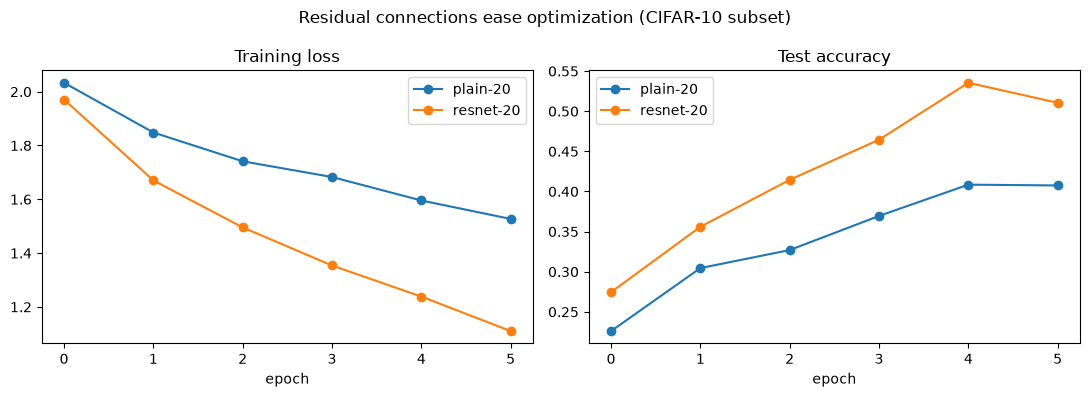

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(plain_loss, marker="o", label="plain-20"); ax[0].plot(res_loss, marker="o", label="resnet-20")
ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(plain_acc, marker="o", label="plain-20"); ax[1].plot(res_acc, marker="o", label="resnet-20")
ax[1].set_title("Test accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.suptitle("Residual connections ease optimization (CIFAR-10 subset)"); plt.tight_layout(); plt.show()